In [2]:
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import binary_dilation
from skimage.transform import rotate
import os
import numpy as np
import matplotlib.pyplot as plt
import pathlib

import numpy as np
import tifffile as tiff
from skimage.transform import resize
from skimage import util
from skimage.io import imread
from skimage.filters import  threshold_triangle, median
from skimage.exposure import adjust_gamma
from skimage.measure import label,  regionprops_table
from skimage.morphology import remove_small_holes,  disk, remove_small_objects 
from skimage import exposure, feature
from skimage.filters import sobel

from skimage.measure import label, regionprops, moments_central
from scipy.ndimage import rotate, binary_dilation
from skimage.draw import polygon
import tifffile

from pathlib import Path
import numpy as np
import tifffile as tiff

In [35]:
def central_rect_from_mask(mask, angle_deg, width_frac=0.92, min_run_frac=0.25):
    """
    Returns central rectangle corners (x,y) in original image coords,
    excluding necks by keeping only the band where cross-section width is near-max.

    width_frac: keep rows whose width >= width_frac * max_width
    min_run_frac: minimum run length (fraction of device length) to accept
    """
    # rotate so device is axis-aligned; rotate uses CCW degrees
    m = rotate(mask.astype(float), -angle_deg, order=0) > 0.5

    H, W = m.shape
    rows = np.where(m.any(axis=1))[0]
    if rows.size == 0:
        return None

    y0, y1 = rows[0], rows[-1]
    band = m[y0:y1+1]

    # per-row left/right edges and width
    any_row = band.any(axis=1)
    x_left  = np.full(band.shape[0], np.nan, dtype=float)
    x_right = np.full(band.shape[0], np.nan, dtype=float)

    rr = np.where(any_row)[0]
    cols = np.argmax(band[rr], axis=1)
    x_left[rr] = cols
    x_right[rr] = band.shape[1] - 1 - np.argmax(band[rr, ::-1], axis=1)

    widths = x_right - x_left
    maxw = np.nanmax(widths)
    keep = widths >= (width_frac * maxw)

    # find longest contiguous run of keep==True
    k = keep.astype(np.int8)
    d = np.diff(np.r_[0, k, 0])
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    if starts.size == 0:
        return None

    run_lengths = ends - starts
    best = np.argmax(run_lengths)
    s, e = starts[best], ends[best]

    # enforce minimum run length (optional)
    if run_lengths[best] < min_run_frac * (y1 - y0 + 1):
        # fallback: just take central third
        mid = (y1 - y0 + 1) // 2
        half = int(0.15 * (y1 - y0 + 1))
        s, e = max(0, mid - half), min(band.shape[0], mid + half)

    # rectangle bounds in rotated coords
    y_top = y0 + s
    y_bot = y0 + (e - 1)
    xl = np.nanmedian(x_left[s:e])
    xr = np.nanmedian(x_right[s:e])

    corners_rot = np.array([
        [xl, y_top],
        [xr, y_top],
        [xr, y_bot],
        [xl, y_bot],
    ], dtype=np.float32)

    # rotate corners back to original coords
    cy, cx = (H - 1) / 2.0, (W - 1) / 2.0
    theta = np.deg2rad(angle_deg)
    R = np.array([[ np.cos(theta), -np.sin(theta)],
                  [ np.sin(theta),  np.cos(theta)]], dtype=np.float32)

    # note: corners are (x,y). convert to centered (x-cx, y-cy), rotate, shift back
    XY = corners_rot - np.array([cx, cy], dtype=np.float32)
    XY2 = (R @ XY.T).T + np.array([cx, cy], dtype=np.float32)

    return XY2  # (4,2) corners in original image coords (x,y)

In [40]:
unseen_image_folder = Path(r"Z:\Bel\Vascumap_Example_Lifs\training_data\downsampled_4\in_focus_each_point")
tif_files = list(unseen_image_folder.glob("*.tif"))
print(len(tif_files))


181


In [43]:

j = 170
img = imread(tif_files[j]).astype(np.float32)
print(img.max(), img.min())
def signed_orientation(region):
    img = region.image.astype(float)
    mu = moments_central(img)
    y20 = mu[2, 0]
    y02 = mu[0, 2]
    y11 = mu[1, 1]
    angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
    return np.rad2deg(angle_rad)

median_img = median(img, footprint=disk(5))   # try disk(1..3)


sobel_img = sobel(median_img)
adjusted = adjust_gamma((median_img), gamma=0.7, gain=1)
sobel_adjusted = sobel(adjusted)
thresh = threshold_triangle(sobel_adjusted)
binary = sobel_adjusted > thresh

labels = label(binary)

data = regionprops_table(labels, binary, properties=("label", "area", "eccentricity"))  
condition = (data['area'] > 100) & (data['area'] < 20000) & (data['eccentricity'] > 0.5)
labels_to_dilate = util.map_array(labels, data['label'], data['label'] * condition) 
dilated_output = np.zeros_like(labels, dtype=np.uint8)

for region in regionprops(labels_to_dilate):
    region_label = region.label
    mask = labels_to_dilate == region_label
    angle_to_rotate = signed_orientation(region)
    selem = np.zeros((31, 31), dtype=bool)
    selem[15, :] = 1
    rotated_selem = rotate(selem.astype(float), angle=90 + angle_to_rotate, reshape=False, order=0) > 0.5
    dilated = binary_dilation(mask, structure=rotated_selem)
    dilated_output[dilated] = 255
final_mask = np.logical_or(dilated_output, binary)

clean_mask = remove_small_objects(final_mask.astype(bool), min_size=5000)
clean_mask = remove_small_holes(clean_mask, area_threshold=10000)

clean_labels = label(util.invert(clean_mask))

props = regionprops(clean_labels)

label_sizes = {p.label: p.area for p in props}
largest_label = max(label_sizes, key=label_sizes.get)
device_mask = remove_small_holes(clean_labels == largest_label, area_threshold=100000)
corners = central_rect_from_mask(device_mask, angle_deg=0.0, width_frac=0.92, min_run_frac=0.25)


2047.0 113.5625


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_535036\1058395950.py:40: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean_mask = remove_small_objects(final_mask.astype(bool), min_size=5000)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_535036\1058395950.py:41: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller on

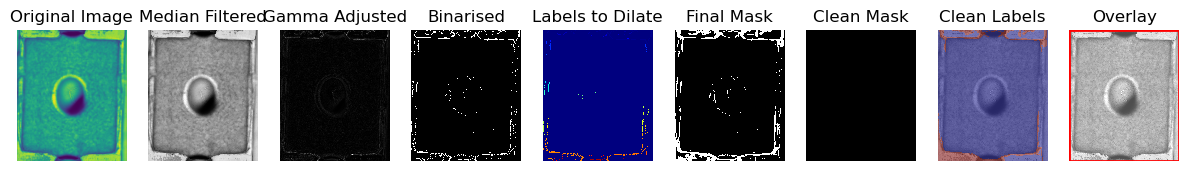

In [44]:
fig, ax = plt.subplots(ncols=9, figsize=(15,5))
titles = ['Original Image', 'Median Filtered', "Gamma Adjusted", 'Binarised', 'Labels to Dilate', 'Final Mask', "Clean Mask", "Clean Labels", "Overlay"]
ax[0].imshow(img)
ax[1].imshow(median_img, interpolation = "none", cmap='gray')
ax[2].imshow(sobel_adjusted, interpolation = "none", cmap='gray')
ax[3].imshow(binary, interpolation = "none", cmap='gray')
ax[4].imshow(labels_to_dilate, interpolation = "none", cmap="jet")
ax[5].imshow(final_mask, interpolation = "none", cmap='gray')
ax[6].imshow(device_mask, interpolation = "none", cmap='gray')

ax[7].imshow(img, alpha = 0.7, cmap="gray", interpolation = "none")
ax[7].imshow(np.ma.masked_where(device_mask == 0, clean_mask), cmap="jet", alpha=0.5, interpolation="none")
ax[8].imshow(img, alpha = 0.7, cmap="gray", interpolation = "none")
ax[8].plot(
    np.r_[corners[:, 0], corners[0, 0]],
    np.r_[corners[:, 1], corners[0, 1]],
    "-r", linewidth=2
)
for i, axis in enumerate(ax):
    ax[i].axis('off')
    ax[i].set_title(titles[i])
plt.savefig("device_segmentation_conventional_methods_output_{}.pdf".format(j), transparent=True)